# 생성 모델

## 1. 생성 모델의 개념  
  
### 1-1. 분류 모델 vs 생성 모델  
  
**생성 모델**: 주어진 데이터를 학습해, 학습 데이터의 분포를 따르는 유사한 데이터를 생성하는 모델  
  
> 단순히 데이터를 복제하는 것이 아니라, 데이터가 가진 '특징의 분포'를 배워서 그 분포 내에 존재할 법한 새로운 데이터를 샘플링하는 과정  
  
- 분류 모델
    - 훈련 데이터의 각 샘플에 정답 레이블 존재
    - 입력 데이터가 어떤 레이블에 속하는지 결정하는 모델
    - X가 주어졌을 때 정답이 Y일 확률 계산
    - 한계: 본적 없는 데이터가 들어와도 어떻게든 기존에 배운 라벨 중하나로 결론을 내림
  
- 생성 모델
    - 데이터 자체의 확률 분포를 학습하여, 학습 데이터와 유사한 새로운 데이터를 만들어내는 모델
    - 세상에 존재할 법한 데이터 X 자체의 확률 분포 파악
    - 이상한 입력에 대해서는 거부하기도 함

### 1-2. 생성 모델 분류  
  
> "확률 밀도를 직접 계산할 수 있는가?"라는 기준에 따라 명시적 모델과 암시적 모델로 분류  
  
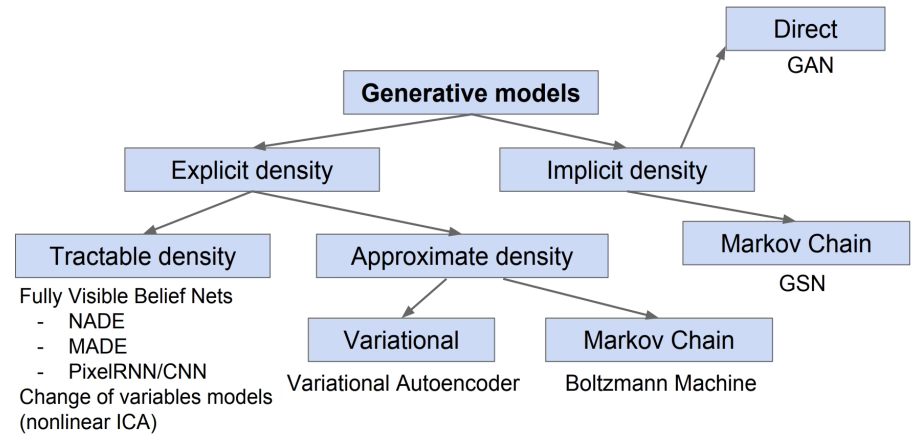  
  
1. 명시적 확률밀도 모델
- 모델이 데이터의 확률 분포인 P(X) 값을 직접적으로 수치화하여 출력할 수 있는 모델
- 정확히 계산 가능한 모델: 수학적으로 확률 값 정확히 계산 가능
    - ex. 자기회귀 모델: 픽셀 하나하나를 순서대로 예측하며 전체 확률 곱해서 구함
- 근사적 밀도 모델: 확률 값을 정확히 구하기는 복잡해서, 그 근삿값이나 하한선을 계산
    - ex. VAE: 정확한 확률 대신 ELBO 수치를 최대화하는 방식으로 학습
  

  
2. 암시적 확률밀도 모델
- 데이터의 확률 분포 P(X)가 무엇인지 수치로 알려주지 X, 그래도 그 분포를 따르는 데이터를 생성할 수 있는 있음
- 직접 샘플링: 신경망을 한 번 통과시키는 것만으로 데이터를 바로 만들어냄
    - ex. GAN: 가짜와 진짜를 비교하며 샘플링 능력 키움
- 간접/반복적 샘플링 (마르코브 체인): 여러 단계를 거쳐 점진적으로 데이터 완성
    - 수식 한 번으로 이미지가 나타나는 것이 아니라, 이전 단계의 상태를 바탕으로 다음 단계를 예측하는 과정을 반복하며 최종 데이터 분포에 도달
    - ex. GSN: 데이터의 확률 분포를 직접 계산하는 대신, 데이터 분포로 수렴하는 마르코프 연쇄 전이 연산자 학습하여 다음에 어떤 데이터 생성할지 결정하는 규칙을 딥러닝으로 학습
    - ex. 확산 모델: 노이즈를 여러 단계에 걸쳐 조금씩 제거하며 이미지 생성

## 2. AE, VAE  
  
### 2-1. AE  
  
**AE**: Auto Encoder, 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망  
- 차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등 데이터 복원이나 특성 학습에 많이 사용됨
- 일반적인 인코더, 디코더와 다르게, 정답지 없이 입력 데이터를 그대로 다시 그려내는 것을 목적으로 함
  

[AE 구조와 작동]  
  
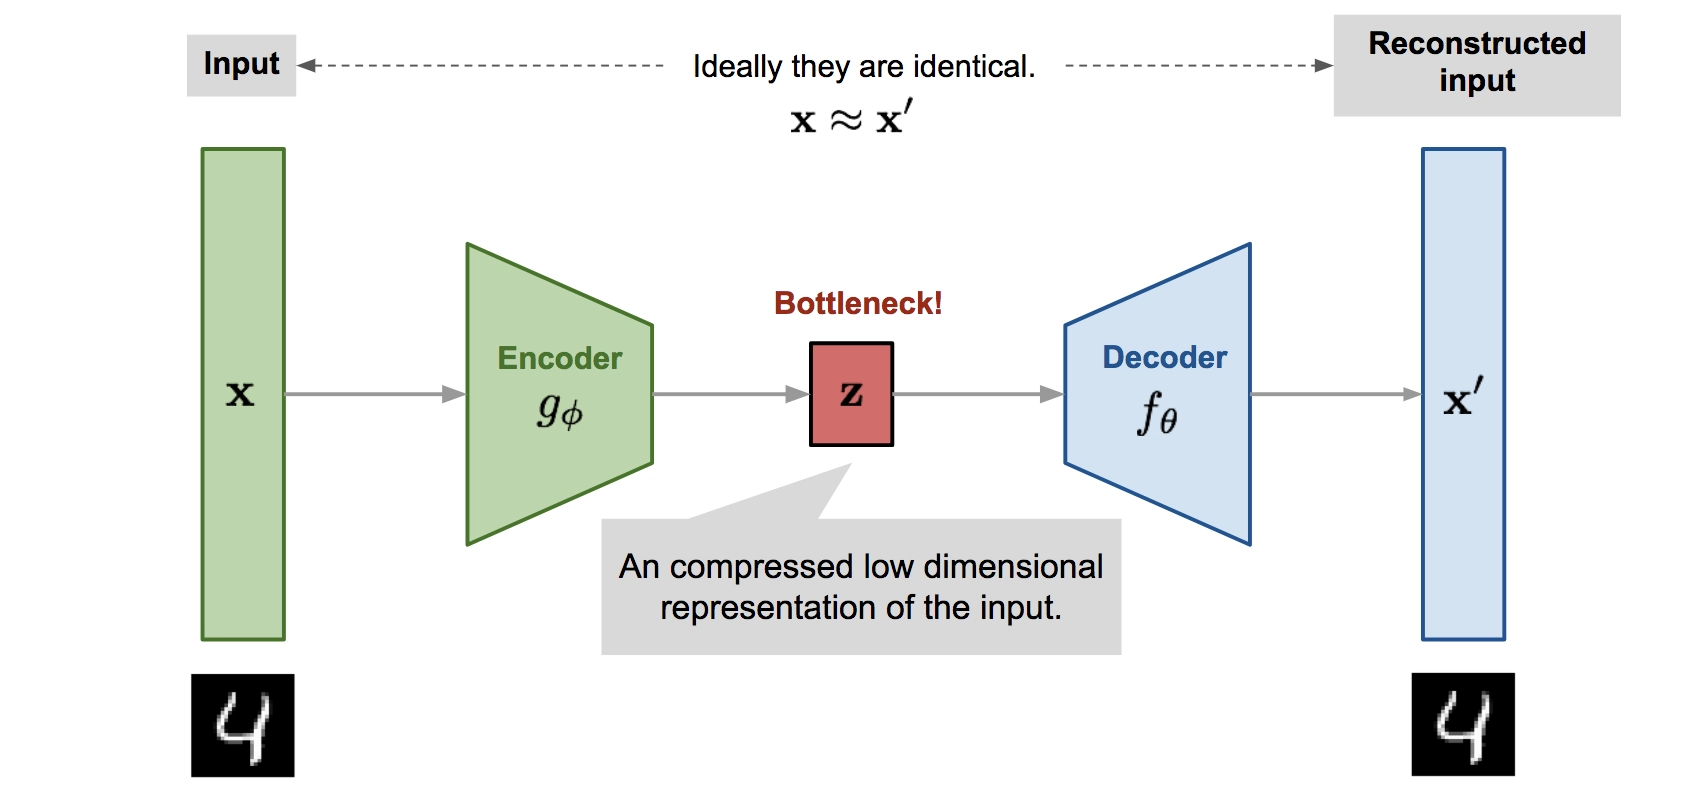  
  
1. 압축 (Encoder)
- 방대한 정보를 가진 입력 데이터를 잠재 벡터로 통과시키기 위해 핵심만 남김
- 인코더: 원래의 고차원 입력 데이터를 잠재 표현으로 변환하는 네트워크
  
2. 병목 통과 (Bottleneck)
- 가장 중요한 정보만 남은 상태, 이 좁은 구간을 잠재 벡터(Latent Vector)라고 함
- 잠재 벡터: 원본 데이터를 저차원으로 압축하여 함축된 정보를 저장하고 있는 벡터
    - 학습 과정에서 겉으로 드러나지 않는 숨겨진 특징 정보 저장
    - ex. 물체의 형상, 카메라 좌표, 광원 정보 등 함축적으로 저장
  
3. 복원 (Decoder)
- 바늘구멍을 통과한 핵심 정보를 단서로, 다시 원래의 커다란 이미지로 복원
- 디코더: 잠재 표현을 풀어서 입력을 재복원하여 출력하는 네트워크
  

> 위 과정을 통해 모델이 노이즈를 버리고 데이터의 본질을 학습하게 만듦  
  

### 2-2. VAE  
  
**VAE**: Variational Auto Encoder, 데이터의 잠재적인 구조를 학습하여, 원본과 닮았지만 새로운 데이터를 생성해내는 모델  
  
> 이미지 생성, 텍스트 생성, 신호처리, 이미지 보간 등 새로운 데이터를 생성하는 작업에 많이 사용  
  
- AE의 한계: AE는 데이터를 잠재 공간의 특징 점으로만 봄 -> 학습할 때 쓰지 않은 빈공간의 점을 찍으면, 디코더는 엉뚱한 결과를 출력함
- VAE 해결책: 잠재 벡터를 점이 아닌 가우시안 분포(범위)로 학습 -> 어떤 점을 뽑아도 그럴듯한 이미지 생성 가능
  
**AE vs VAE**  
  
> 입력 데이터를 잠재 공간에 어떤 형태로 배치하느냐  
  
- AE: 잠재 공간의 어떤 하나의 점으로 매핑
    - (-)한 번도 데이터가 찍히지 않은 빈 공간의 좌표를 만났을 때 의미 없는 노이즈를 출력함
  
- VAE: 잠재 코드 값이 평균과 분산으로 표현되는 어떤 확률 분포
    - 연속적, 조밀함
    - (+) 임의의 지점을 샘플링하더라도 자연스럽고 새로운 결과물 만들어냄
  
=> 원본 데이터를 재생하는 데 있어서, AE에 비해 VAE는 *잠재 공간이 연속적이고 체계적으로 정리되어 있음* -> 새로운 데이터를 생성하는 능력 탁월!  
  
[VAE 구조와 작동]  
  
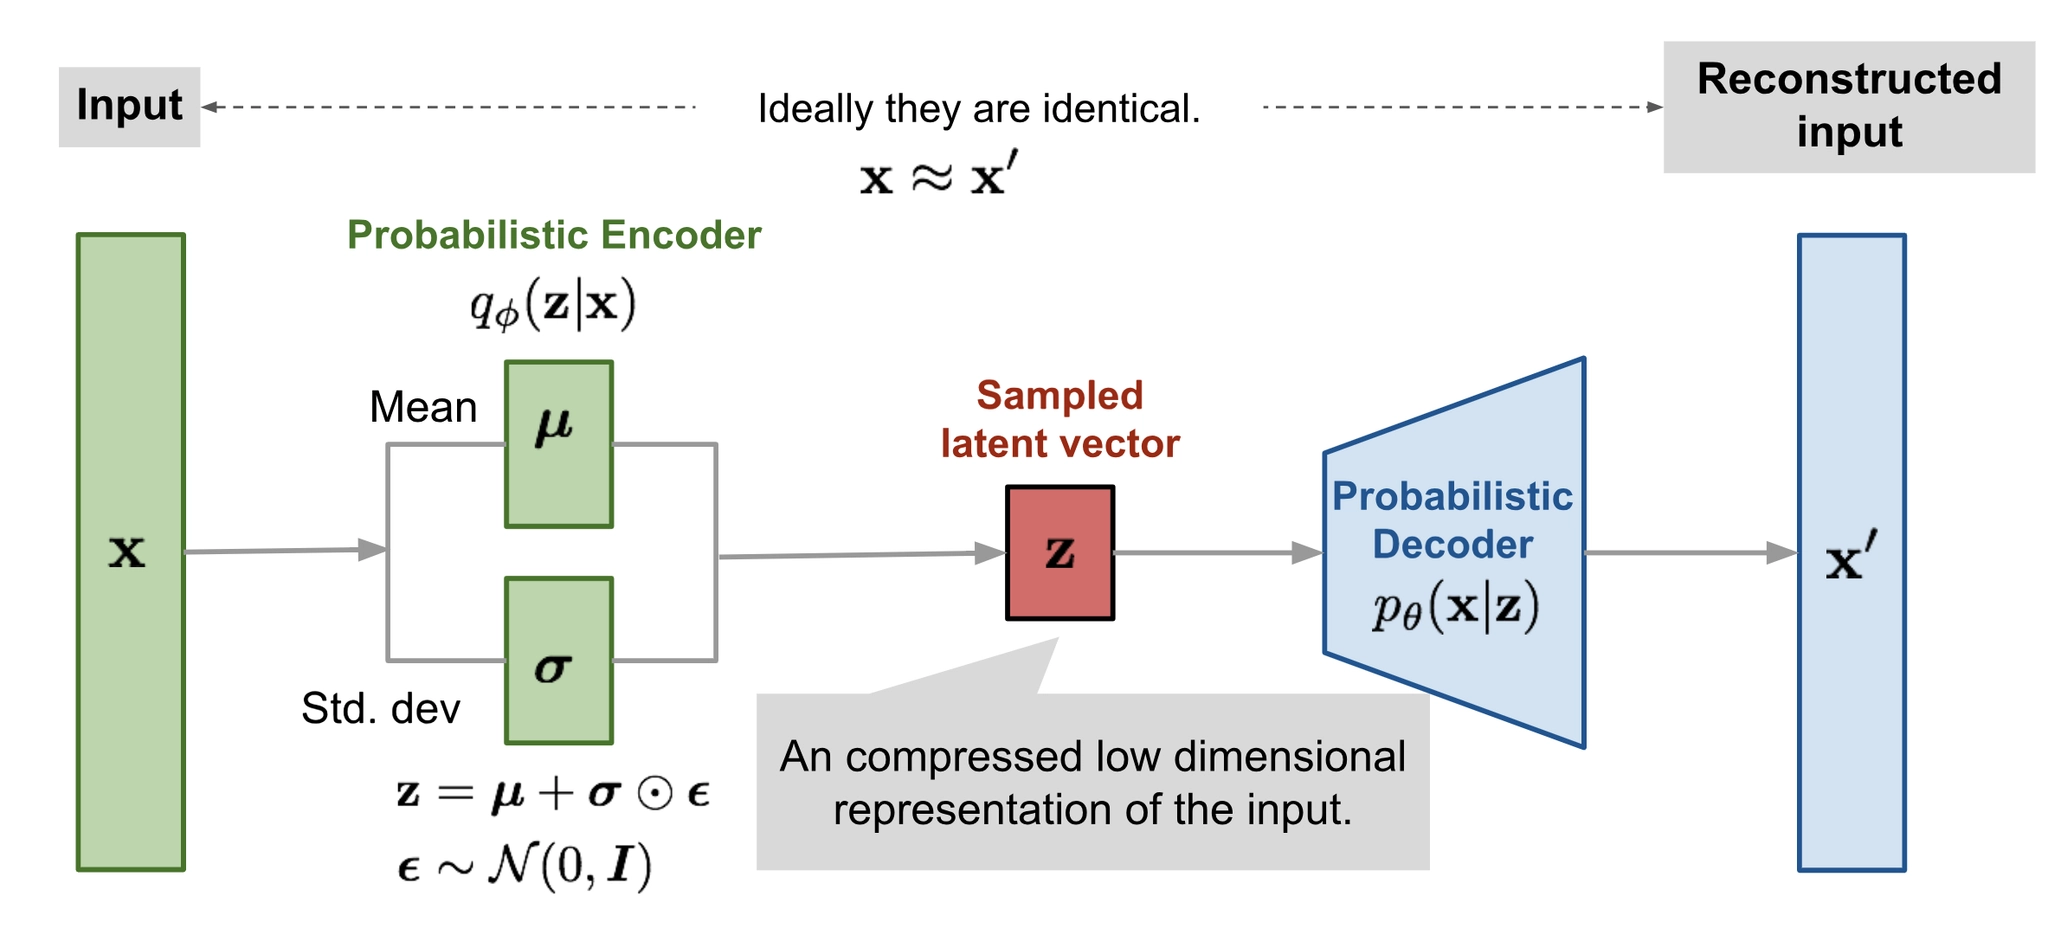  
  
1. 분포 예측 (Encoder)
- 입력 데이터를 점이 아니라, 데이터가 존재할 확률이 높은 '구역'으로 매핑
- 인코더: 입력 데이터를 분석해 잠재 공간상의 평균과 표준편차 계산
    - 이 데이터는 잠재 공간 내에서 평균이 $\mu$이고 퍼짐 정도가 $\sigma$인 영역에 위치할 확률이 높다고 정의함
  
2. 샘플링 및 재파라미터화
- 예측한 분포에서 실제 디코더에 전달할 잠재 벡터를 하나 뽑음
- 샘플링: 인코더가 찾은 범위($\mu$, $\sigma$) 안에서 무작위로 점 하나를 추출
- 잠재 벡터: 인코더가 출력한 분포에서 무작위로 추출된 벡터
- 재파라미터화 트릭
    - 문제: 무작위 샘플링은 수학적으로 미분 불가 (=역전파 학습 불가)
    - 해결: 무작위성($\epsilon$)을 공식 밖으로 빼서 노이즈처럼 더해주는 방식 사용
    - 공식: $z=\mu+\sigma\odot\epsilon$
    - 효과: 무작위성은 유지하면서, 분포를 인공지능이 학습할 수 있는 상태가 됨
  
3. 생성 (Decoder)
- 샘플링된 잠재 벡터를 단서로 사용하여 새로운 데이터 생성
- 디코더: 저차원의 핵심 정보를 다시 고차원의 데이터로 복원
    - 새로운 데이터를 만들어내는 생성기 (AE는 잘 압축되는지 검증하는 도구, VAE 디코더는 새로운 데이터를 만듦)

## 3. GAN  
  
### 3-1. GAN 개념  
  
**GAN**: Generative Adversarial Network, 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하면서 훈련을 통해 자신의 작업을 점점 더 정교하게 수행하는 신경망 모델  
  
- 적대적 학습: 생성자와 판별자가 서로 적대적으로 학습
    - 결국 생성자는 진짜와 구분이 불가능한 데이터를 만들어내고
    - 판별자는 진짜와 가짜를 찍어서 맞히는 수준(확률 0.5)에 도달
  
[목적]  
- 생성자: 진짜 분포에 가까운 가짜 분포를 생성
- 판별자: 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지를 결정
  
> 궁극적으로 "실제 데이터 분포"에 가까운 데이터를 생성하며 판별자가 진짜/가짜를 한 쪽으로 판단하지 못하는 경계를 최적 솔루션으로 간주함  
  
[구조]  
- 두 개의 신경망이 최소-최대 게임(MinMax Game)을 수행하는 구조
  
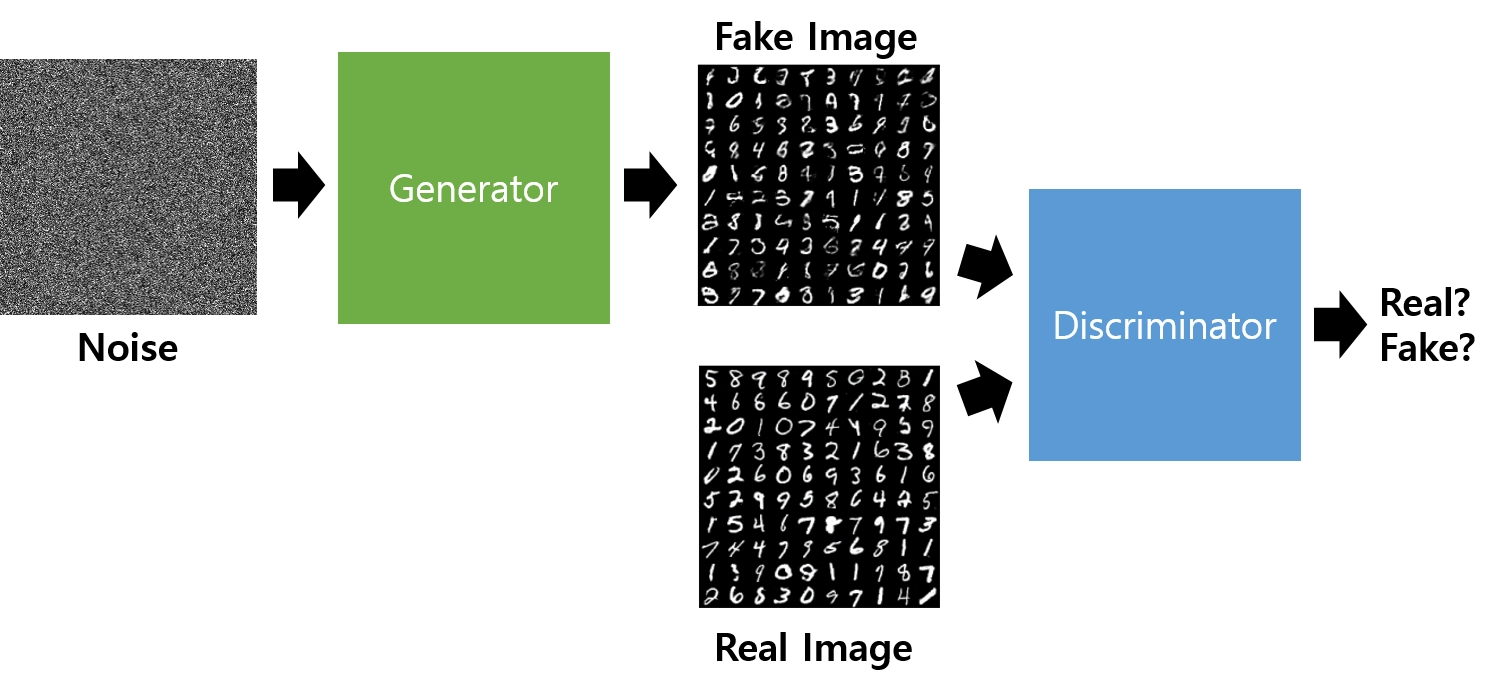  
  
- 생성자
    - 입력: 우리가 직접 제어할 수 있는 무작위 노이즈(잠재 변수)
    - 출력: 실제 데이터와 유사한 가짜데이터
    - 목표: 판별자를 속여서 가짜를 진짜(1)로 믿게 만듦
  
- 판별자
    - 입력: 실제 데이터와 가짜 데이터
    - 출력: 입력 데이터가 진짜일 확률 출력
    - 목표: 진짜는 1, 가짜는 0으로 정확히 분류하는 모델
  
[장단점]  
- 장점
    - 진짜 같은 가짜 생성
    - 선명도: VAE는 수학적 평균을 취해서 흐릿한 이미지 생성, But GAN은 판별자를 통과하여 선명한 샘플
      
    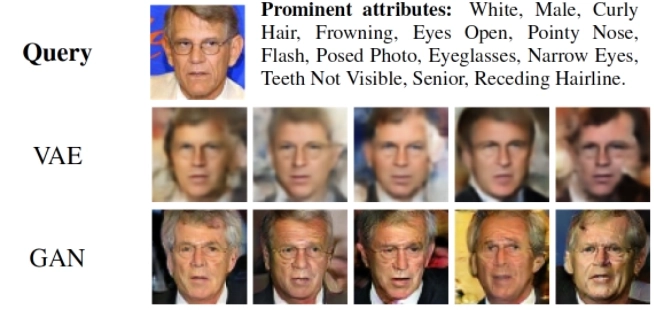  
      
    
    - 빠른 생성 속도: 여러 단계를 거치지 않고 신경망을 한 번만 통과
    - 잠재 공간 부드러움: 이미지가 부드럽게 변하는 보간이 가능
  
- 단점
    - 학습의 불안정성: 에폭이 진행될수록 손실 값이 떨어지지 않고 위아래로 요동치는 진동 현상, 무한 루프로 업데이트
    - 훈련 초기 그래디언트 소멸 문제: 초기에 판별자가 가짜를 너무 쉽게 잡아내서 진짜처럼 보일 수 있는 힌트 자체가 사라짐
    - 모드 붕괴: 생성자가 판별자를 속이기 쉬운 특정 패턴 하나만 주구장창 학습 (다양한 이미지를 만들지 못함)
    - 지표 부재: 객관적인 손실 곡선 없음
    - 역매핑 불가능: 잠재 변수 자체를 추출하는 과정(인코더 역할)이 없음
  
[적용 사례]  
1. NVIDIA(2017): 가짜 이미지 생성
  
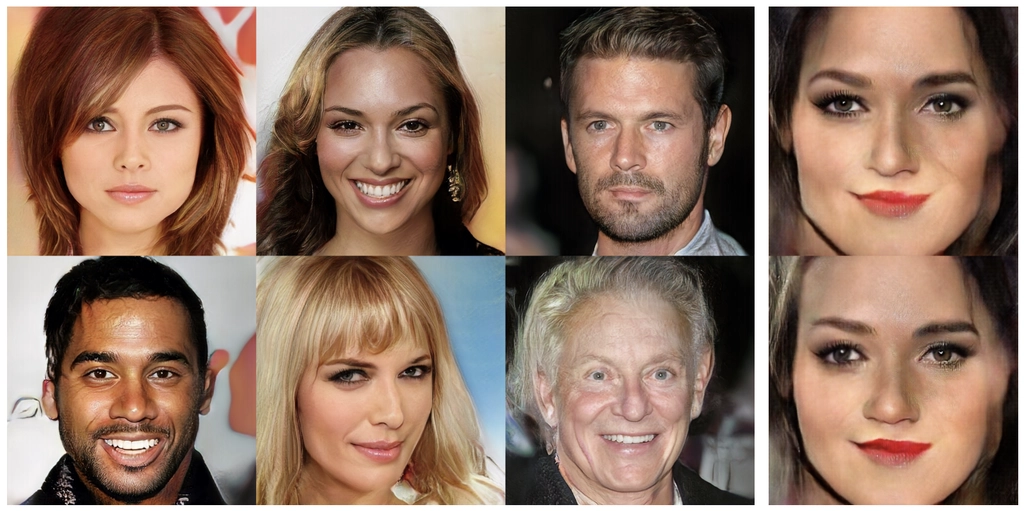  
  
- 생성자와 판별자 모두 낮은 결과값에서 시작하여 훈련이 진행되면서 모델이 아주 서서히 학습하도록 점진적으로 성장시킴
- 사람뿐 아니라 사물도 실제와 같은 이미지로 만들어낼 수 있음
  
2. University of Washington(2017): 가짜 오바마 연설
  
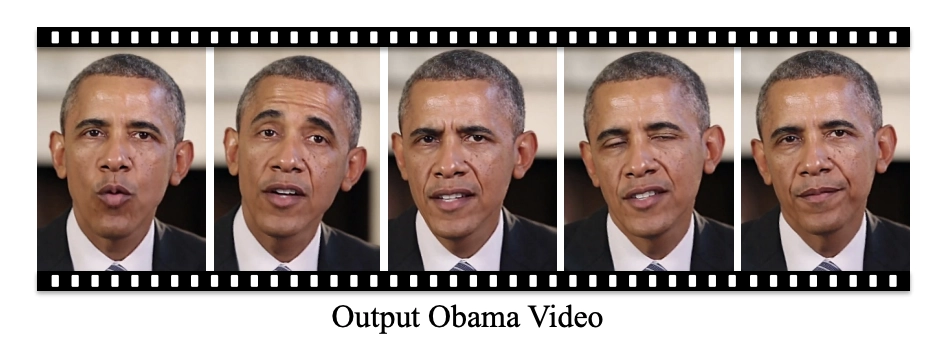  
  
- 오바마 전 대통령의 과거 연설 영상들로부터 합성한 가짜 영상
  
3. Facebook(2017): Eye In-Painting
  
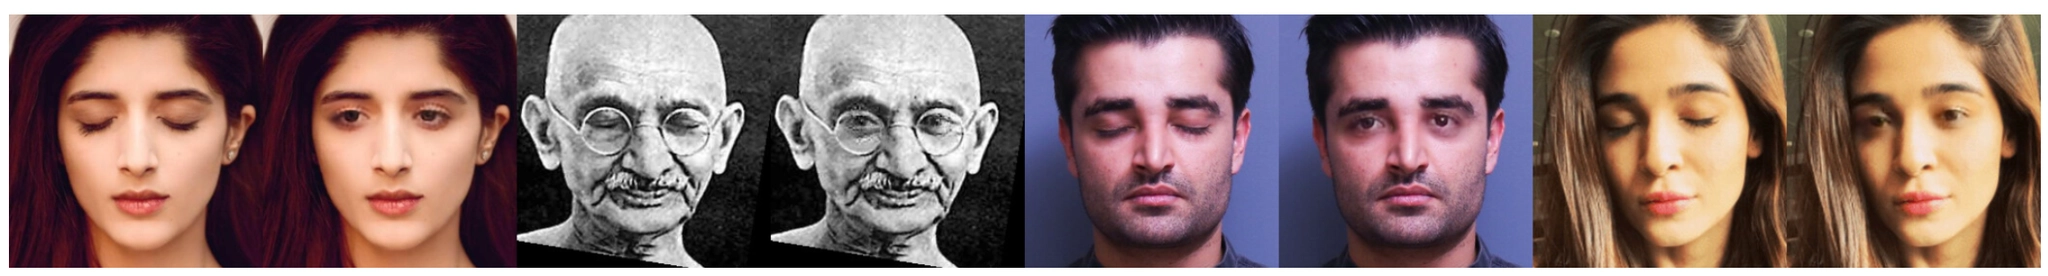  
  
- GAN을 이용해 진짜 같은 가짜 눈을 만들어 눈을 감은 사진에 합성 시킴


## 4. 확산 모델  
  
### 4-1. 확산 모델 개념  
  
**확산 모델**: Diffusion Model (원본 데이터 -> 노이즈 -> 원본 데이터)  
1. 입력 이미지에 노이즈를 조금씩 추가하여 완전한 노이즈로 만든 뒤
2. 이를 다시 거꾸로 복원하는 과정을 학습하여 (노이즈 제거)
3. 입력 이미지와 유사한 확률 분포를 가진 결과 이미지 생성하는 모델
  
- 목표: 순확산과 역확산 단계를 거쳐 생성된 결과 이미지의 확률 분포를 원래 데이터의 확률 분포와 최대한 유사하게 만듦
- 모호성 모델링: 모호한 요청에 대해, 완전한 노이즈 상태에서 시작해 데이터 구조의 아주 작은 부분을 조금씩 상상하며 구체적인 이미지로 완성해 나감
  
### 4-2. 확산 모델 구조: 순확산과 역확산  
  
**순확산**  
  
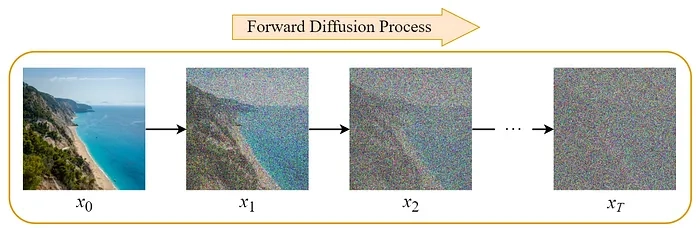  
  
> 데이터에 점진적으로 노이즈를 추가하는 과정  
  
1. 시작: 깨끗한 원본 데이터에서 시작
2. 노이즈 추가: 원본 데이터에 점진적으로 노이즈를 추가, 이 단계는 여러 번 반복됨
3. 결과: 위 단계가 계속 반복되어 원본 데이터가 무작위 노이즈로 변함
  
  
**역확산**  
  
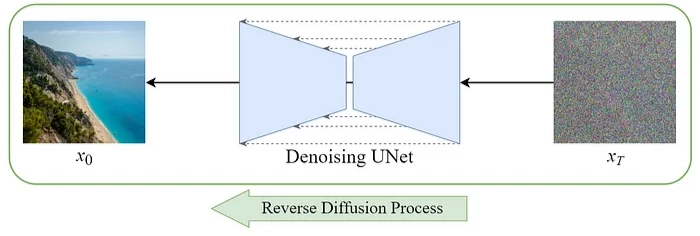  
  
> 노이즈 데이터에서 원본 데이터를 재구성하는 과정  
  
1. 시작: 완전한 노이즈 데이터에서 시작
2. 노이즈 제거: 각 단계에서 어떤 노이즈가 추가되었을지 예측하며 점진적으로 노이즈를 제거
3. 결과: 반복적인 디노이징 과정을 거쳐 점진적으로 이미지 복원  
  
[장단점]  
- 장점
    - 샘플 품질: GAN보다 정교하고 다양한 이미지를 생성할 수 있으며, 고해상도 확장에 유리 (한 번에 찍어내지 않고 조금씩 다듬으며 결과물을 도출해내기 때문)
    - 학습 안정성: 손실 곡선(MSE) 확인 가능
    - 다양성: 모드 붕괴 현상 거의 나타나지 않음
  
- 단점
    - 느린 생성 속도: 반복 시간이 필요해서 오래 걸림
    - 높은 계산 비용: 컴퓨팅 자원 필요
    - 구조적 제약: 노이즈 분포와 데이터 형태 동일해야 함

# AI 최적화

## 0. AI 최적화와 정렬  
  
[문제1] 이 거대한 모델을 어떻게 써먹지?  
- **전이학습 + 경량화**: 이미 학습된 모델을 가져다가 내 용도에 맞게 조금만 손보자!  
  
[문제2] 이 모델이 진짜 사람에게 도움이 돼?  
- **AI 정렬**: 모델이 사람의 의도랑 가치에 맞게 행동하도록 맞춰주자.  

## 1. 전이학습과 딥러닝 경량화  
  
### 1-1. 전이학습  
  
**딥러닝 모델의 한계**  
- 데이터 부족, 계산 시간과 비용 증가, 과적합 발생
  
> 어디선가 학습된 내용을 가져다가 쓰자! (=전이학습)  
  
**전이학습**: Source Domain과 Target Domain이 서로 다르거나 Source Task와 Target Task가 서로 다른 상황에서 Source Domain과 Source Task에서 얻은 지식을 이용해 Target Domain 위의 Target Task의 성능을 향상시킴  
  
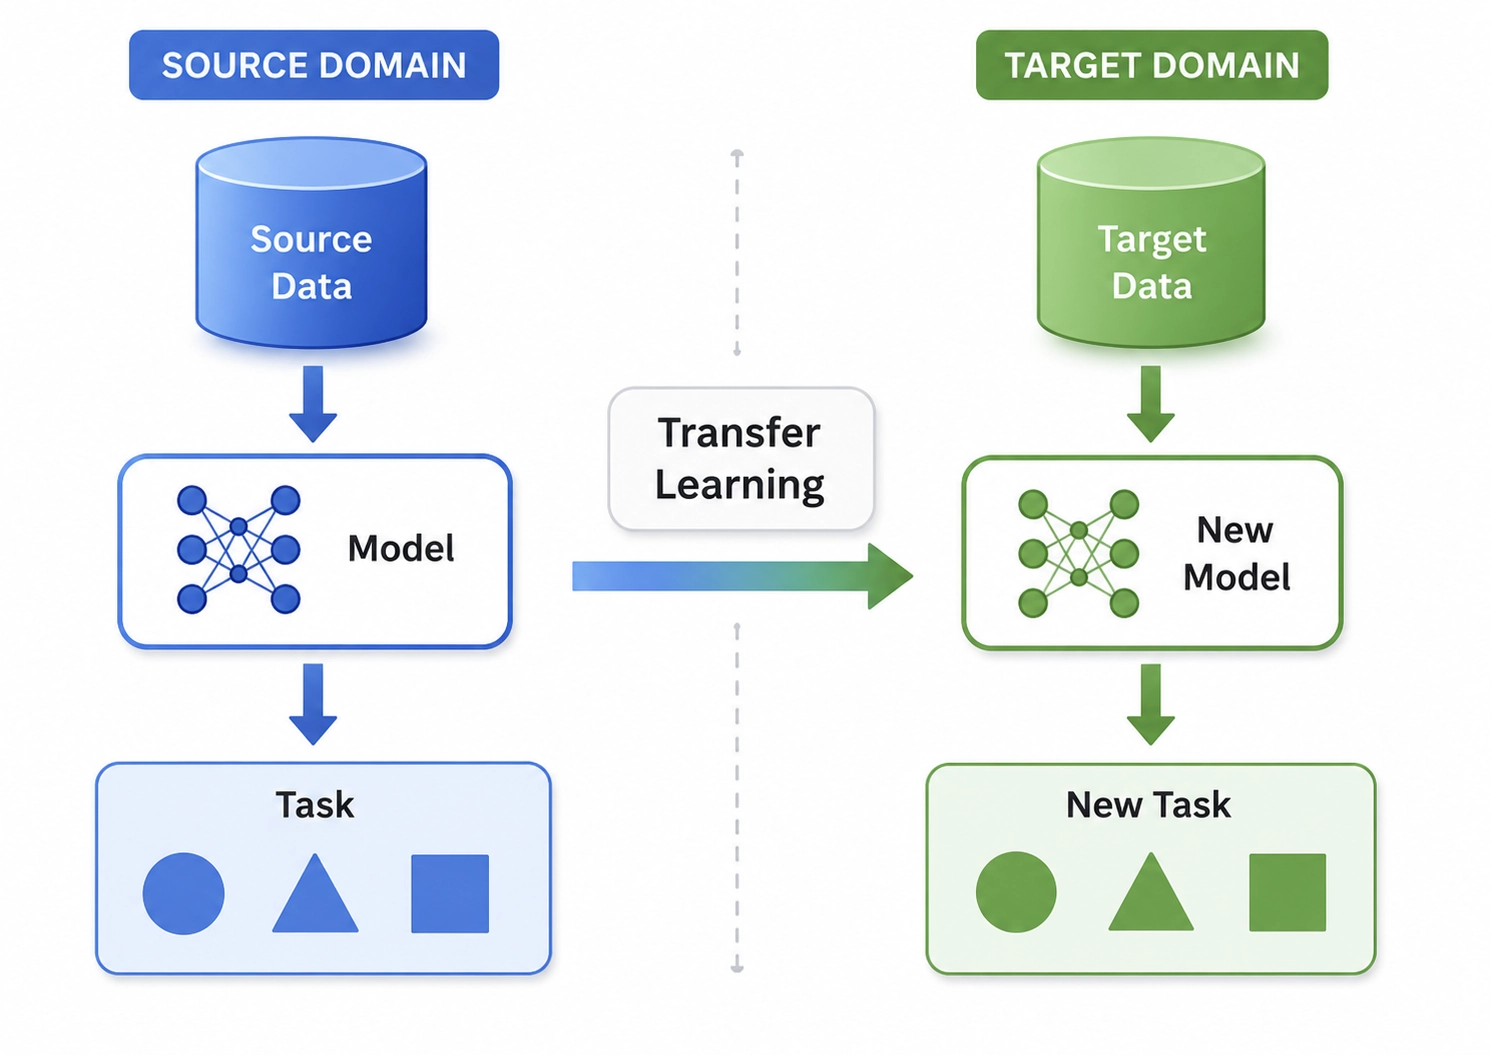  
  

- Domain: 어떤 데이터를 다루고 있는가
- Task: 그 데이터로 무엇을 예측하는가
- Source: 전이학습의 출발점, 이미 학습 완료된 모델이 있는 곳
- Target: 도착점, 내가 실제로 풀고 싶은 문제
  
> 데이터나 문제 유형이 달라도, 다른 상황에서 배운 지식을 가져와 새로운 상황에서 성능을 높이는 것  
  
  
### 1-2. 전이학습의 분류  
  
[기준1: 도메인과 태스크]  
  
1. 귀납적 전이학습 (Inductive TL): 소스와 타겟의 task가 다르고, 타겟 도메인에 라벨이 존재 (=파인튜닝 가능)  
  
2. 트랜스듀서형 전이학습 (Transductive TL): 소스와 타겟의 task는 같지만 도메인 다름 (타겟에 라벨 없어도 적용 가능)  
  
3. 비지도 전이학습 (Unsupervised TL): 소스와 타겟의 task가 다르고 소스와 타겟 모두 라벨이 없을 때 
  
  
[기준2: 무엇을 전이하느냐]  
  
1. 인스턴스 (Instance): 소스 데이터 중 타겟에 도움이 될만한 샘플을 골라 가중치 부여 (데이터 라벨의 전이)  
  
2. 특징 (Featrue): 소스와 타겟의 공통적인 특징을 추출할 수 있는 표현 방식을 전이 (표현 label 전이)  
  
3. 파라미터 (Parameter): 모델의 가중치나 하이퍼파라미터 초기값 전이 (ex. GPT, BERT)  
  
4. 관계 (Relation): 데이터 간 논리적 관계나 구조적 지식 전이  
  
  
### 1-3. 전이학습의 현재 패러다임: Pre-training & Fine-tuning  
  
[트랜스포머 이전의 전이학습]  
- 사전 학습된 좋은 모델이라는 개념 자체가 당연하지 않음
- 각자 처음부터 모델을 만듦
- 전이학습은 주로 CNN의 ImageNet 가중치를 가져오는 수준
  
[트랜스포머 이후의 전이학습]  
- Pre-training & Fine-tuning 패러다임: 이미 잘 학습된 거대 모델을 내 용도에 맞게 어떻게 조정하지?
- 파운데이션 모델: GPT나 Gemini처럼 수만 가지 일을 할 수 있는 지능의 기반이 되는 거대 모델
    - 텍스트, 이미지, 비디오 등 다양한 형식의 데이터를 학습할 수 있음
- Fine-tuning: 파운데이션 모델을 내 용도에 맞게 조정
  

### 1-4. Fine-tuning의 한계를 넘어서  
  
**PEFT**: Parameter-Efficient Fine-Tuning, 최소한의 파라미터만 건드려서 최대의 성능을 내자  
- 원래 모델의 파라미터는 고정하고 별도의 작은 파라미터만 추가적으로 학습
  
**Zero-shot & Few-shot**  
- 모델이 파라미터를 업데이트 하지 않음
- Zero-shot Transfer: 학습 데이터 없어도, 언어 이해 능력만을 기반으로 바로 추론을 수행
- Few-shot Transfer: 극소수의 예시만으로 새로운 태스크 수행
  

### 1-5. 전이학습의 한계  
- Negative Transfer: Source와 Target의 도메인이 너무 다르면 오히려 전이가 성능 떨어트림
    - Maximum Mean Discrepancy: 도메인 간 거리 측정 지표
  
- Catastrophic Forgetting: 파인 튜닝 과정에서 새 데이터에 너무 치우치면 모델이 원래 가진 일반화 능력 상실
    - Elastic Weight Consolidation: 중요한 가중치는 최대한 바꾸지 않음으로써, 일반화 능력을 유지하자
  
- Bias Transfer: 사전 학습 데이터에 담긴 편향이 그대로 넘어 옴
  
- Transferability 측정 어려움: 어떤 두 태스크가 얼마나 관련되어 있는지를 사전에 정량적으로 측정하기 어려움
  
  
### 1-6. 전이학습 사용 사례  
  
1. 컴퓨터 비전: 의료 영상 분석, 자율주행
2. 자연어 처리: 법률 문서 분석, 기업 특화 챗봇
3. 의료, 신약 개발: 단백질 구조 예측
4. 제조 산업: 공장 불량 검출
  

### 1-7. 딥러닝 경량화  
  
**딥러닝 경량화**: 대규모 및 복잡한 인공지능 모델을 가벼운 형태로 변환하는 기술  
- 성능을 최대한 유지하면서 모델을 가볍게 만드는 것이 핵심
  
[가지치기]  
- 모델의 파라미터 중 영향력이 적은 가중치를 제거
  
[양자화]  
- 모델의 가중치를 표현하는 숫자의 정밀도를 줄임
    - ex. float를 int로 바꾸기
  
[지식 증류]  
- 크고 복잡한 모델이 작은 모델에게 가르쳐 주는 방식
  
[모델 구조 경량화]  
- 처음부터 가볍게 설게된 모델을 씀
    - 모바일, 엣지 디바이스용으로 처음부터 작게 설계된 경우
  
[하드웨어 가속화]  
- 특정 연산을 빠르게 수행할 수 있는 전용 하드웨어 활용

## 2. AI Alignment  
  
### 2-1. AI Alignment 정의  
  
**인공지능 정렬**: 단순히 모델의 성능을 높이는 단계를 넘어, 인간의 의도, 목표, 윤리적 가치에 부합하도록 행동  
  
- Helpful / Honest / Harmless 지표를 기준으로 정렬
  
1. Outer Alignment  
  
> 목표를 제대로 설정했는가?  
  
- AI에게 보상을 주는 기준을 제대로 설정하여 꼼수를 부리는 현상을 해결
- RLHF
  
2. Inner Alignment  
  
> 모델이 내면에서 무엇을 최적화하는가?  
  
- 인간의 감시가 없을 때 AI가 기만적으로 자신의 원래 목표를 수행하도록 행동이 바뀜
- 모델의 실제 내부 동작을 해석 가능하게 만드는 해석 가능성 연구가 중요해짐  
  

[정렬을 어렵게 만드는 요인]  
- 가치 정렬의 모호성: 사람마다 가치가 달라서 어떤 기준에 맞춰야 할지 정하기 어려움
- 확장 가능한 감독: AI가 인간보다 똑똑해지는 영역에서 인간이 AI의 답변을 판단하기 어려워짐
  

### 2-2. RLHF  
  
**RLHF**: Reinforcement Learning from Human Feedback, 인간의 피드백을 기반으로 모델을 강화학습으로 조정하는 방법  
  
- 답변 내용의 정답 여부보다, 어떤 답변을 인간이 선호하는지 학습하고 이를 통해 사람이 더 좋아하는 답을 하도록 만듦
- 과정
    1. 지도 미세 조정 (SFT): 인간의 지시를 따르는 방법을 배움
    2. 보상 모델 학습 (RM): 인간의 선호도에 따라 점수를 매기는 채점기 만듦
    3. 강화 학습 (RL): 보상 모델을 기준으로 언어 모델의 성능을 극대화하는 최적화 단계  
- 주의: 인간이 좋아할 법한 대답만 골라하는 기만적 행동을 보일 수 있음

## 3. 프롬프트 엔지니어링  
  
### 3-1. 프롬프트 엔지니어링 정의  
  
**프롬프트 엔지니어링**: AI가 더 좋은 답변을 내도록 입력을 설계하는 기술  
  
> 모델은 그대로 두고 입력만 잘 설계해서 원하는 답을 이끌어내는 것  
  
### 3-2. 주요 기법  
  
1. Zero-shot / Few-shot Prompting
- Zero-shot: 예시 없이 바로 질문
- Few-shot: 예시를 몇 개 보여주고 질문
    - zero-shot보다 성능 좋음
  
2. Chain-of-Thought (CoT)
- 답만 내놓으라고 하지 말고, 풀이 과정을 단계별로 생각하게 만듦
  
3. Role Prompting
- AI에게 특정 역할을 맡겨서 그 역할에 맞는 답변을 끌어냄
- 구체적인 페르소나를 부여할수록 답변이 일관되고 전문적
  
4. Instruction Prompting
- 원하는 걸 최대한 구체적으로 지시
- 출력 형식, 길이, 톤을 구체적으로 지정
  
5. Self-Consistency
- 같은 질문을 여러 번 해서 가장 많이 나온 답을 채택
  
6. RAG  
- 최신 정보다 특정 도메인 지식을 외부 데이터베이스에서 검색해 프롬프트에 함께 넣어 줌
  

### 3-3. 프롬프트 엔지니어링 한계  
  
1. 프롬프트 주입 공격: 악의적인 사용자가 프롬프트 조작해서 AI 엉뚱하게 동작시키는 보안 문제
2. 할루시네이션: 아무리 프롬프트 잘써도 환각 현상 발생 가능
3. 모델 의존성: 모델마다 프롬프트 다르게 반응함
4. 성능 한계: 프롬프트 엔지니어링만으로는 Fine-tuning 수준의 성능 내기 어려운 경우도 존재